In [94]:
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import numpy as np

In [3]:
# pip install openpyxl


In [4]:
gender_data = pd.read_csv("./data/gender.csv")
categories = pd.read_excel("./data/CLASS.xlsx")
aid = pd.read_csv("./data/aid-effectiveness.csv")
growth = pd.read_csv("./data/economy-and-growth.csv")


In [5]:
# Gender data preprocessing
exists_series = gender_data.agg(pd.notnull).mean()
sorted = gender_data.sort_values(by = ["Year", "Country Name"])
drops = []
for index, percent in enumerate(exists_series):
    if percent < 0.5:
        drops.append(index)
sorted = sorted.drop(sorted.columns[drops], axis = 1)
names = {}
for column in sorted.columns:
    if column.startswith('average_value'):
        names[column] = column.strip('average_value_')
sorted = sorted.rename(columns = names)
gender = sorted
gender['life_expectancy_parity'] =  gender["Life expectancy at birth, female (years)"] / gender["Life expectancy at birth, male (years)"]

In [6]:
gender = gender.merge(categories, how = "left", left_on = "Country Code", right_on= "Code")

In [7]:
gender.columns.to_frame().reset_index(drop = True).rename(columns = {0: "Gender Columns"})
# .iloc[3].to_dict()

,Gender Columns
0,Country Name
1,Country Code
2,Year
3,"Adolescent fertility rate (births per 1,000 wo..."
4,"Fertility rate, total (births per woman)"
5,"Life expectancy at birth, female (years)"
6,"Life expectancy at birth, male (years)"
7,"Mortality rate, adult, female (per 1,000 femal..."
8,"Mortality rate, adult, male (per 1,000 male ad..."
9,"School enrollment, secondary, female (% gross)"


In [8]:
numeric = gender.drop(columns = ["Country Name", "Country Code", "Economy", "Code", "Income group", "Lending category"])
regions = numeric.groupby(["Region", "Year"]).mean().reset_index()

In [9]:
regions

,Region,Year,"Adolescent fertility rate (births per 1,000 women ages 15-19)","Fertility rate, total (births per woman)","Life expectancy at birth, female (years)","Life expectancy at birth, male (years)","Mortality rate, adult, female (per 1,000 female adults)","Mortality rate, adult, male (per 1,000 male adults)","School enrollment, secondary, female (% gross)","School enrollment, secondary, male (% gross)","Secondary education, general pupils (% female)","Secondary education, pupils (% female)","Survival to age 65, female (% of cohort)","Survival to age 65, male (% of cohort)",life_expectancy_parity
0,East Asia & Pacific,1960,69.190652,5.979065,56.788323,52.662346,293.910903,362.418290,NaN,NaN,NaN,NaN,54.009061,45.058267,1.078183
1,East Asia & Pacific,1961,68.716955,5.945323,57.273032,53.129129,289.148387,357.856161,NaN,NaN,NaN,NaN,54.729213,45.706943,1.077776
2,East Asia & Pacific,1962,68.243258,5.901323,57.761323,53.592613,284.583355,353.361032,NaN,NaN,NaN,NaN,55.449364,46.355619,1.077516
3,East Asia & Pacific,1963,67.455335,5.843677,58.280097,54.081871,279.069613,347.406742,NaN,NaN,NaN,NaN,56.230473,47.087601,1.077335
4,East Asia & Pacific,1964,66.667413,5.760806,58.788419,54.561129,273.507774,341.899226,NaN,NaN,NaN,NaN,57.011583,47.819582,1.077167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,Sub-Saharan Africa,2016,99.525175,4.502562,63.745604,59.788104,244.003062,302.217417,51.820486,54.113653,47.360801,47.187368,63.278436,54.787066,1.065979
423,Sub-Saharan Africa,2017,97.717917,4.435917,64.164812,60.232188,238.236979,296.165917,51.753626,52.122734,49.211001,48.880978,64.228313,55.640996,1.065168
424,Sub-Saharan Africa,2018,96.024654,4.368146,64.539833,60.557229,233.163167,298.065604,54.741304,54.573112,49.355109,49.673052,64.723689,56.101275,1.065617
425,Sub-Saharan Africa,2019,94.331392,4.300604,64.914146,60.901667,229.728229,294.629583,49.667971,49.682173,49.498120,48.884770,65.219065,56.561554,1.065707


In [10]:
px.line(regions, color = 'Region', x = "Year", y = "Adolescent fertility rate (births per 1,000 women ages 15-19)")

In [11]:
aid.notna().mean()

Country Name                                                                                        1.000000
Country Code                                                                                        1.000000
Year                                                                                                1.000000
average_value_Grants, excluding technical cooperation (BoP, current US$)                            0.593453
average_value_Incidence of tuberculosis (per 100,000 people)                                        0.309362
average_value_Maternal mortality ratio (modeled estimate, per 100,000 live births)                  0.287241
average_value_Mortality rate, under-5 (per 1,000 live births)                                       0.818095
average_value_Net ODA received (% of GNI)                                                           0.623313
average_value_Net ODA received (% of gross capital formation)                                       0.530032
average_value_Net O

In [13]:
growth.columns

Index(['Country Name', 'Country Code', 'Year',
       'average_value_DEC alternative conversion factor (LCU per US$)',
       'average_value_Discrepancy in expenditure estimate of GDP (current LCU)',
       'average_value_GDP (constant 2010 US$)',
       'average_value_GDP (constant LCU)', 'average_value_GDP (current LCU)',
       'average_value_GDP (current US$)',
       'average_value_GDP deflator (base year varies by country)',
       'average_value_GDP growth (annual %)',
       'average_value_GDP per capita (constant 2010 US$)',
       'average_value_GDP per capita (constant LCU)',
       'average_value_GDP per capita (current LCU)',
       'average_value_GDP per capita (current US$)',
       'average_value_GDP per capita growth (annual %)',
       'average_value_GDP per capita, PPP (constant 2017 international $)',
       'average_value_GDP per capita, PPP (current international $)',
       'average_value_GDP, PPP (constant 2017 international $)',
       'average_value_GDP, PPP (

In [43]:
growth_small = growth[["Country Name", "Country Code", "Year", 
                       "average_value_GDP growth (annual %)", "average_value_GDP per capita growth (annual %)",
                       'average_value_GDP per capita (current US$)']]
growth_small = growth_small[growth_small['average_value_GDP growth (annual %)'].notna()]
growth_small.columns = [column.replace("average_value_", "").replace(" ", "_").lower() for column in growth_small.columns]

In [44]:
growth_small

,country_name,country_code,year,gdp_growth_(annual_%),gdp_per_capita_growth_(annual_%),gdp_per_capita_(current_us$)
0,Arab World,ARB,1988,5.650656,2.714793,2019.827199
4,Burundi,BDI,2008,4.861713,1.456551,198.352852
5,Belgium,BEL,2018,1.787920,1.325650,47554.746308
6,Belgium,BEL,1966,3.155895,2.461462,1957.626080
8,Canada,CAN,2017,3.039880,1.811115,45129.356440
...,...,...,...,...,...,...
15578,Uruguay,URY,1996,5.577958,4.826677,6317.561877
15579,St. Vincent and the Grenadines,VCT,1987,0.438075,-0.214410,1657.907062
15580,Vanuatu,VUT,2013,0.468608,-2.323437,2954.774511
15581,World,WLD,1998,2.560055,1.152410,5273.857683


In [74]:
merged = growth_small.merge(gender, left_on = ["country_name", "country_code", "year"], right_on = ["Country Name", "Country Code", "Year"])
merged = merged.drop(columns= ["Code"])

In [77]:
def get_country(country, code):
    if code:
        return merged[merged["country_code"] == country].sort_values(by = "year").set_index("year")
    else:
        return merged[merged["country_name"] == country].sort_values(by = "year").set_index("year")

In [78]:
get_country('World', False).columns

Index(['country_name', 'country_code', 'gdp_growth_(annual_%)',
       'gdp_per_capita_growth_(annual_%)', 'gdp_per_capita_(current_us$)',
       'Country Name', 'Country Code', 'Year',
       'Adolescent fertility rate (births per 1,000 women ages 15-19)',
       'Fertility rate, total (births per woman)',
       'Life expectancy at birth, female (years)',
       'Life expectancy at birth, male (years)',
       'Mortality rate, adult, female (per 1,000 female adults)',
       'Mortality rate, adult, male (per 1,000 male adults)',
       'School enrollment, secondary, female (% gross)',
       'School enrollment, secondary, male (% gross)',
       'Secondary education, general pupils (% female)',
       'Secondary education, pupils (% female)',
       'Survival to age 65, female (% of cohort)',
       'Survival to age 65, male (% of cohort)', 'life_expectancy_parity',
       'Economy', 'Region', 'Income group', 'Lending category'],
      dtype='object')

In [82]:
japan_data = get_country("Japan", False)
indonesia_data = get_country("Indonesia", False)

In [92]:
# plot data
fig1 = px.line(japan_data, x = "Year", y = 'Fertility rate, total (births per woman)')
fig2 = px.line(japan_data, x = "Year", y = 'gdp_per_capita_growth_(annual_%)')

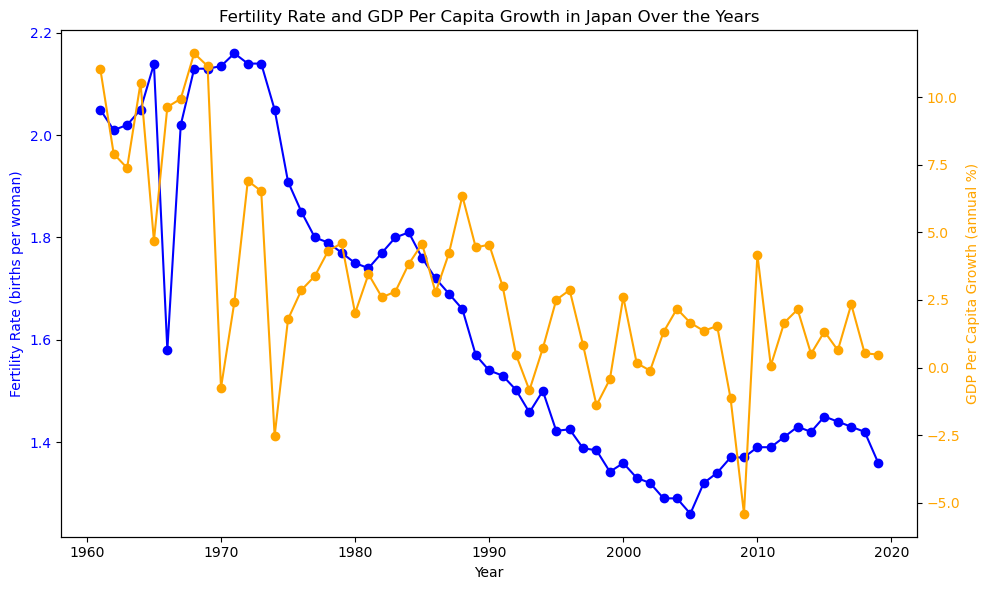

In [99]:
import matplotlib.pyplot as plt

# Assuming japan_data is a pandas DataFrame
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotting Fertility Rate
ax1.plot(japan_data['Year'], japan_data['Fertility rate, total (births per woman)'], marker='o', label='Fertility Rate (births per woman)', color='blue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Fertility Rate (births per woman)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Creating a second y-axis for GDP Per Capita Growth
ax2 = ax1.twinx()
ax2.plot(japan_data['Year'], japan_data['gdp_per_capita_growth_(annual_%)'], marker='o', label='GDP Per Capita Growth (annual %)', color='orange')
ax2.set_ylabel('GDP Per Capita Growth (annual %)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Adding title and legend
plt.title('Fertility Rate and GDP Per Capita Growth in Japan Over the Years')
fig.tight_layout()
plt.show()

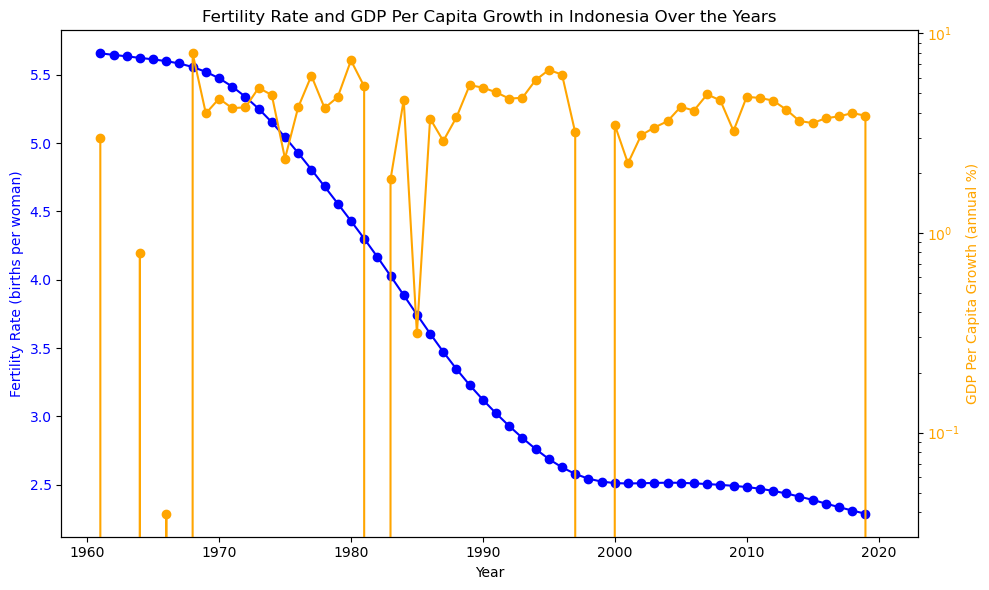

In [98]:
import matplotlib.pyplot as plt

# Assuming indonesia_data is a pandas DataFrame
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotting Fertility Rate
ax1.plot(indonesia_data['Year'], indonesia_data['Fertility rate, total (births per woman)'], marker='o', label='Fertility Rate (births per woman)', color='blue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Fertility Rate (births per woman)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Creating a second y-axis for GDP Per Capita Growth
ax2 = ax1.twinx()
ax2.plot(indonesia_data['Year'], indonesia_data['gdp_per_capita_growth_(annual_%)'], marker='o', label='GDP Per Capita Growth (annual %)', color='orange')
ax2.set_ylabel('GDP Per Capita Growth (annual %)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Set the y-axis to logarithmic scale for GDP per capita growth
ax2.set_yscale('log')

# Adding title and legend
plt.title('Fertility Rate and GDP Per Capita Growth in Indonesia Over the Years')
fig.tight_layout()
plt.show()

In [100]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add Fertility Rate trace
fig.add_trace(go.Scatter(
    x=indonesia_data['Year'],
    y=indonesia_data['Fertility rate, total (births per woman)'],
    mode='lines+markers',
    name='Fertility Rate (births per woman)',
    line=dict(color='blue')
))

# Add GDP Per Capita Growth trace
fig.add_trace(go.Scatter(
    x=indonesia_data['Year'],
    y=indonesia_data['gdp_per_capita_growth_(annual_%)'],
    mode='lines+markers',
    name='GDP Per Capita Growth (annual %)',
    line=dict(color='orange')
))

# Update layout
fig.update_layout(
    title='Fertility Rate and GDP Per Capita Growth in Indonesia Over the Years',
    xaxis_title='Year',
    yaxis_title='Fertility Rate (births per woman)',
    yaxis2=dict(
        title='GDP Per Capita Growth (annual %)',
        overlaying='y',
        side='right',
        showgrid=False,
        type='log'  # Set logarithmic scale
    )
)

# Show figure
fig.show()

In [103]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add Fertility Rate trace
fig.add_trace(go.Scatter(
    x=japan_data['Year'],
    y=japan_data['Fertility rate, total (births per woman)'],
    mode='lines+markers',
    name='Fertility Rate (births per woman)',
    line=dict(color='blue')
))

# Add GDP Per Capita Growth trace
fig.add_trace(go.Scatter(
    x=japan_data['Year'],
    y=japan_data['gdp_per_capita_growth_(annual_%)'],
    mode='lines+markers',
    name='GDP Per Capita Growth (annual %)',
    line=dict(color='orange')
))

# Update layout
fig.update_layout(
    title='Fertility Rate and GDP Per Capita Growth in Japan Over the Years',
    xaxis_title='Year',
    yaxis_title='Fertility Rate (births per woman)',
    yaxis2=dict(
        title='GDP Per Capita Growth (annual %)',
        overlaying='y',
        side='right',
        showgrid=False,
        type='log'  # Set logarithmic scale
    )
)

# Show figure
fig.show()

In [102]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add Fertility Rate trace
fig.add_trace(go.Scatter(
    x=indonesia_data['Year'],
    y=indonesia_data['Fertility rate, total (births per woman)'],
    mode='lines+markers',
    name='Fertility Rate (births per woman)',
    line=dict(color='blue')
))

# Add GDP Per Capita Growth trace
fig.add_trace(go.Scatter(
    x=indonesia_data['Year'],
    y=indonesia_data['gdp_per_capita_growth_(annual_%)'],
    mode='lines+markers',
    name='GDP Per Capita Growth (annual %)',
    line=dict(color='orange'),
    yaxis='y2'  # Link to secondary y-axis
))

# Update layout for dual y-axes
fig.update_layout(
    title='Fertility Rate and GDP Per Capita Growth in Indonesia Over the Years',
    xaxis_title='Year',
    yaxis_title='Fertility Rate (births per woman)',
    yaxis2=dict(
        title='GDP Per Capita Growth (annual %)',
        overlaying='y',
        side='right',
        type='log'  # Set logarithmic scale
    )
)

# Show figure
fig.show()

In [203]:
import plotly.graph_objects as go

# Assuming japan_data is a pandas DataFrame
fig = go.Figure()
japan_data = get_country("JPN", True)
birthrate_1966 = japan_data[japan_data['Year'] == 1966]['Fertility rate, total (births per woman)'].values[0]

# Fertility Rate trace
fig.add_trace(
    go.Scatter(
        x=japan_data['Year'],
        y=japan_data['Fertility rate, total (births per woman)'],
        mode='lines+markers',
        name='Japanese Fertility Rate (births/woman)',
        line=dict(color='#ff9da7'),
        yaxis='y1'
    )
)

# GDP Per Capita Growth trace
fig.add_trace(
    go.Scatter(
        x=japan_data['Year'],
        y=japan_data['gdp_per_capita_growth_(annual_%)'],
        mode='lines+markers',
        name='Japanese per Capita Growth (%)',
        line=dict(color='#edc949'),
        yaxis='y2'
    )
)

# Layout with dual y-axes
fig.update_layout(
    title=dict(
        text='The Year of the Fire Horse shows up in Japanese Statistics.',
        x=0.5,  # Center the title
        xanchor='center',
        font=dict(size=20, 
                  family = "Calibri")
    ),
    annotations= [dict(
        x=1966,
        y=birthrate_1966,
        xref='x',
        yref='y',
        text='Year of the Fire Horse',
        showarrow=True,
        ax=0,      # shift arrow tail 80 pixels to the right
        ay=40,
        arrowhead=2,       # adds a visible arrow style
        arrowsize=1,
        arrowwidth=2,
        arrowcolor='gray',
        font=dict(color='gray'),
        bgcolor='rgba(255,255,255,0.8)',
        borderwidth=1
    ),         
    dict(
            x=0.5,  # Centered horizontally
            y=1.08,  # Slightly above the main title
            xref='paper',
            yref='paper',
            text="Superstitions say Women born in this year bring bad fortunes. GDP growth and fertility rate aren't correlated.",
            showarrow=False,
            font=dict(size=14, color='gray'),
            xanchor='center'
        )
    ], 
    xaxis=dict(title='Year',
               titlefont=dict(color='#bab0ab'),
               tickfont=dict(color='#bab0ab')),
    yaxis=dict(
        title='Japanese Fertility Rate (births/woman)',
        titlefont=dict(color='#bab0ab'),
        tickfont=dict(color='#ff9da7')
    ),
    yaxis2=dict(
        title='GDP Per Capita Growth (%)',
        titlefont=dict(color='#bab0ab'),
        tickfont=dict(color='#edc949'),
        overlaying='y',
        side='right', 
    ),
    legend=dict(x=0.01, y=0.05),
    width=1000,
    height=600
)



fig.show()

In [196]:
import plotly.graph_objects as go

# Assuming japan_data is a pandas DataFrame
fig = go.Figure()
japan_data = japan_data[japan_data['Year'] < 1970]
birthrate_1966 = japan_data[japan_data['Year'] == 1966]['Fertility rate, total (births per woman)'].values[0]

# Fertility Rate trace
fig.add_trace(
    go.Scatter(
        x=japan_data['Year'],
        y=japan_data['Fertility rate, total (births per woman)'],
        mode='lines+markers',
        name='Japanese Fertility Rate (births/woman)',
        line=dict(color='#ff9da7'),
        yaxis='y1'
    )
)

# GDP Per Capita Growth trace
fig.add_trace(
    go.Scatter(
        x=japan_data['Year'],
        y=japan_data['gdp_per_capita_growth_(annual_%)'],
        mode='lines+markers',
        name='Japanese per Capita Growth (%)',
        line=dict(color='#edc949'),
        yaxis='y2'
    )
)

# Layout with dual y-axes
fig.update_layout(
    title=dict(
        text="Fertility rate suspiciously follows per capita growth.",
        x=0.5,  # Center the title
        xanchor='center',
        font=dict(size=20, 
                  family = "Calibri")
    ),
    annotations= [dict(
        x=1966,
        y=birthrate_1966,
        xref='x',
        yref='y',
        text='Notable dip in 1966',
        showarrow=True,
        ax=80,      # shift arrow tail 80 pixels to the right
        ay=0,
        arrowhead=2,       # adds a visible arrow style
        arrowsize=1,
        arrowwidth=2,
        arrowcolor='gray',
        font=dict(color='gray'),
        bgcolor='rgba(255,255,255,0.8)',
        borderwidth=1
    ),         dict(
            x=0.5,  # Centered horizontally
            y=1.08,  # Slightly above the main title
            xref='paper',
            yref='paper',
            text="Capturing trends in 1960s Japan",
            showarrow=False,
            font=dict(size=14, color='gray'),
            xanchor='center'
        )
    ], 
    xaxis=dict(title='Year',
               titlefont=dict(color='#bab0ab'),
               tickfont=dict(color='#bab0ab')),
    yaxis=dict(
        title='Japanese Fertility Rate (births/woman)',
        titlefont=dict(color='#bab0ab'),
        tickfont=dict(color='#ff9da7')
    ),
    yaxis2=dict(
        title='GDP Per Capita Growth (%)',
        titlefont=dict(color='#bab0ab'),
        tickfont=dict(color='#edc949'),
        overlaying='y',
        side='right', 
    ),
    legend=dict(x=0.1, y=0.2),
    width=1000,
    height=600
)



fig.show()
